# Trajectory Generation with Fixed-k Privacy Protection

This notebook implements experiments for generating and evaluating privacy-protected trajectories using a GRU-based model with a fixed-k approach. It loads the pre-trained models and test data for the Porto and San Francisco datasets, generates protected trajectories for different values of k, and evaluates the results by computing point-to-point distances (MDE) between real and protected trajectories. 

The computed MDE_k values are used for setting up the adaptive k approach.

##### **Imports**

In [ ]:
import os
# oneDNN warning suppression TF 2.4.1
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import copy

import numpy as np
import pandas as pd
import pickle
import statistics

from scipy.stats import energy_distance, wasserstein_distance
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from math import radians
from sklearn.metrics.pairwise import haversine_distances

from utils.data import *
from utils.plots import *
from utils.metrics import *
from models import *
from apu_trajgen import *

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

## **Experiments**

#### **Load Data (Porto dataset)** 

In [2]:
# Load the model generated by the training script from the 'training' folder
selected_dataset = "PORTO"

subset = "test" # or "train" 

# Load the test data
X_t = load_pickle(DATA_FOLDER + selected_dataset.lower() + "_X_"+subset+".pkl") # the input trajectory data
Y_t = load_pickle(DATA_FOLDER + selected_dataset.lower() + "_Y_"+subset+".pkl") # the true values of the trajectory data
traj_seq_lengths = load_pickle(DATA_FOLDER + selected_dataset.lower() + "_seq_len_"+subset+".pkl") # the sequence lenght of the input trajectory data
normalization_ranges = load_pickle(DATA_FOLDER + selected_dataset.lower() + "_normalization_ranges_"+subset+".pkl") # the min and max values for each feature in the trajectory data


#### **Load Model** 

In [3]:
# Load the pre-trained model
mdl = load_pickle(MODEL_FOLDER + "mdlgru-"+selected_dataset.lower()+".pkl")

# Create the model for generating trajectories with BS = 1
model_sl = create_GRU_model(GRU_cells= LSTM_CELLS,
                          seq_len = 1,
                          num_feat = NUM_FEATS,
                          batch_size = 1,
                          stateful = True,
                          return_seq = RETURN_SEQ,
                          num_outputs = NUM_OUTPUTS,
                          LR = LR,
                          SEED = SEED,
                          ragged = False)


# Load the weights and states from the pre-trained model
model_sl.set_weights(mdl.get_weights())

#### **Experiment 1 (Porto dataset) - Fixed k -** 

In [4]:
# Set the number of trajectories to generate/protect
n_trajs = 10

In [5]:
Y_PREDS_Ks = {}

save_pickle(Y_t[:n_trajs], DATA_FOLDER + selected_dataset.lower() + "_Y_test_fixed_k_ntrajs_" + str(n_trajs) + ".pkl")
save_pickle(traj_seq_lengths[:n_trajs], DATA_FOLDER + selected_dataset.lower() + "_test_seq_len_fixed_k_ntrajs_" + str(n_trajs) + ".pkl")

for k in range(1, 6):
    print("Generating trajectories with k = " + str(k))
    
    # Generate the trajectories using the APU Trajectory Generator with fixed k
    # The function apu_trajgen_fixed_k generates trajectories with a fixed k value
    # It uses the model_sl, input trajectory data X_t, sequence lengths traj_seq_lengths,
    # and other parameters to generate the trajectories.3
    Y_pred_k = apu_trajgen_fixed_k(mdl = model_sl,
                                X_t = copy.deepcopy(X_t)[:n_trajs],
                                test_traj_seq_lengths = traj_seq_lengths,
                                SEQ_LENGTH = 1,
                                NUM_FEATS = NUM_FEATS,
                                k_steps=k)
    
    
    save_pickle(Y_pred_k, DATA_FOLDER + selected_dataset.lower() + "_Y_pred_fixed_k_" + str(k) + "_ntrajs_" + str(n_trajs) + ".pkl")
    
    Y_PREDS_Ks[k] = Y_pred_k

Generating trajectories with k = 1
Processing trajectory: 0
Processing trajectory: 1
Processing trajectory: 2
Processing trajectory: 3
Processing trajectory: 4
Processing trajectory: 5
Processing trajectory: 6
Processing trajectory: 7
Processing trajectory: 8
Processing trajectory: 9
Generating trajectories with k = 2
Processing trajectory: 0
Processing trajectory: 1
Processing trajectory: 2
Processing trajectory: 3
Processing trajectory: 4
Processing trajectory: 5
Processing trajectory: 6
Processing trajectory: 7
Processing trajectory: 8
Processing trajectory: 9
Generating trajectories with k = 3
Processing trajectory: 0
Processing trajectory: 1
Processing trajectory: 2
Processing trajectory: 3
Processing trajectory: 4
Processing trajectory: 5
Processing trajectory: 6
Processing trajectory: 7
Processing trajectory: 8
Processing trajectory: 9
Generating trajectories with k = 4
Processing trajectory: 0
Processing trajectory: 1
Processing trajectory: 2
Processing trajectory: 3
Processing

#### **Plot a Trajectory** 

<Figure size 640x480 with 0 Axes>

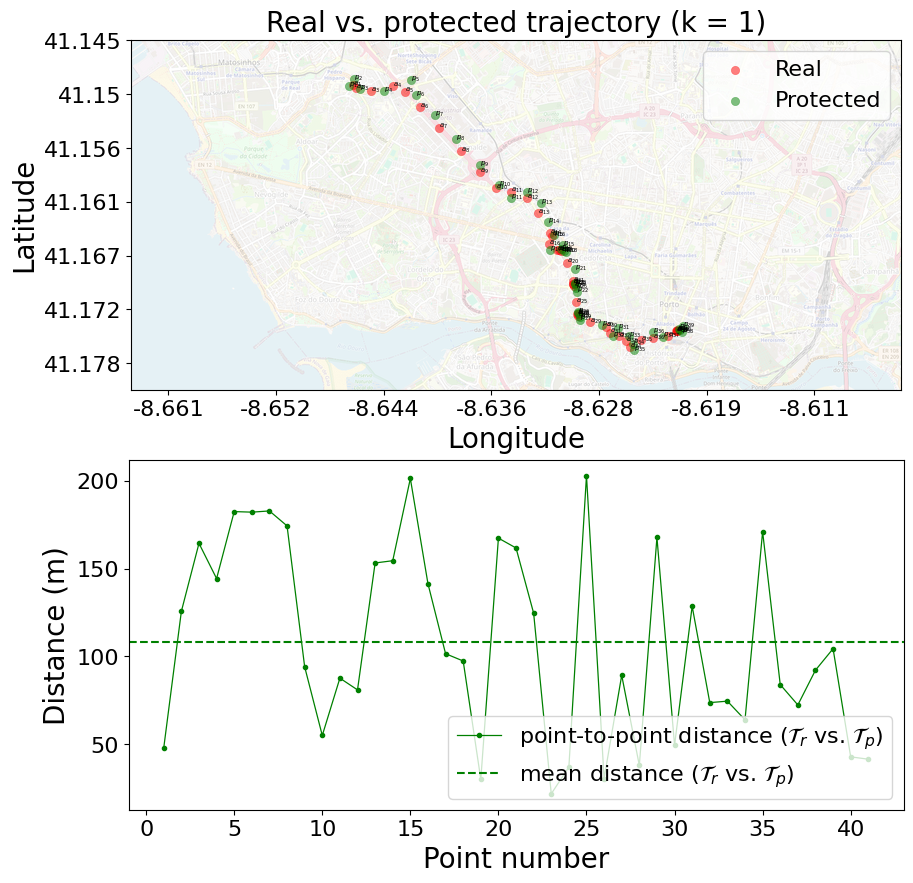

Point-to-point distance between the real and protected trajectory:
[np.float64(47.96908706378516), np.float64(125.62777658031357), np.float64(164.33885362405903), np.float64(144.2877764281149), np.float64(182.41919766052337), np.float64(182.09363595713194), np.float64(182.7859887484335), np.float64(174.2793583056456), np.float64(94.04980627562986), np.float64(54.99231604794757), np.float64(87.60447480765936), np.float64(80.92917525797029), np.float64(153.1680561218862), np.float64(154.45461939005057), np.float64(201.2509671303818), np.float64(141.36431593097342), np.float64(101.5224357395654), np.float64(97.36478600970912), np.float64(29.99926249027974), np.float64(167.31149656755557), np.float64(161.7033916912381), np.float64(124.5689052723524), np.float64(21.771266547825434), np.float64(36.979183046130096), np.float64(202.88266796314736), np.float64(30.46480837137905), np.float64(89.24051337918124), np.float64(37.93254938669263), np.float64(167.6951856786945), np.float64(49.457513100

<Figure size 640x480 with 0 Axes>

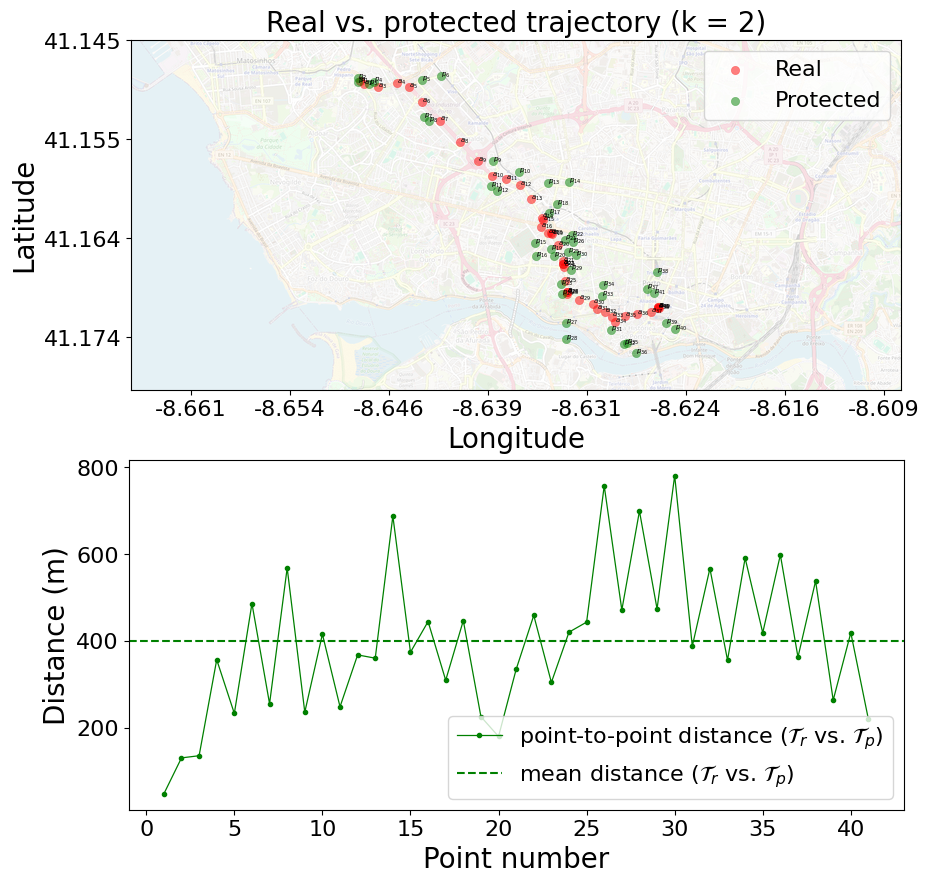

Point-to-point distance between the real and protected trajectory:
[np.float64(47.96908706378516), np.float64(130.64903237513298), np.float64(135.6368570238034), np.float64(356.55066140566566), np.float64(232.9003450587686), np.float64(485.89109276765197), np.float64(255.31047038730915), np.float64(567.7449416223961), np.float64(235.86204187616377), np.float64(415.39532668703174), np.float64(248.27564057556694), np.float64(367.65444965491037), np.float64(360.1015313154079), np.float64(687.2596705866899), np.float64(373.83634549132586), np.float64(444.4179002945703), np.float64(309.3346027319043), np.float64(446.61356981955333), np.float64(225.55778821441373), np.float64(179.87301039555192), np.float64(334.44247978962045), np.float64(458.543219356805), np.float64(304.33710518963227), np.float64(419.9742647308007), np.float64(443.06284024398207), np.float64(756.7033245883744), np.float64(470.98933050885455), np.float64(698.6165720052235), np.float64(473.46895939422717), np.float64(780.18

<Figure size 640x480 with 0 Axes>

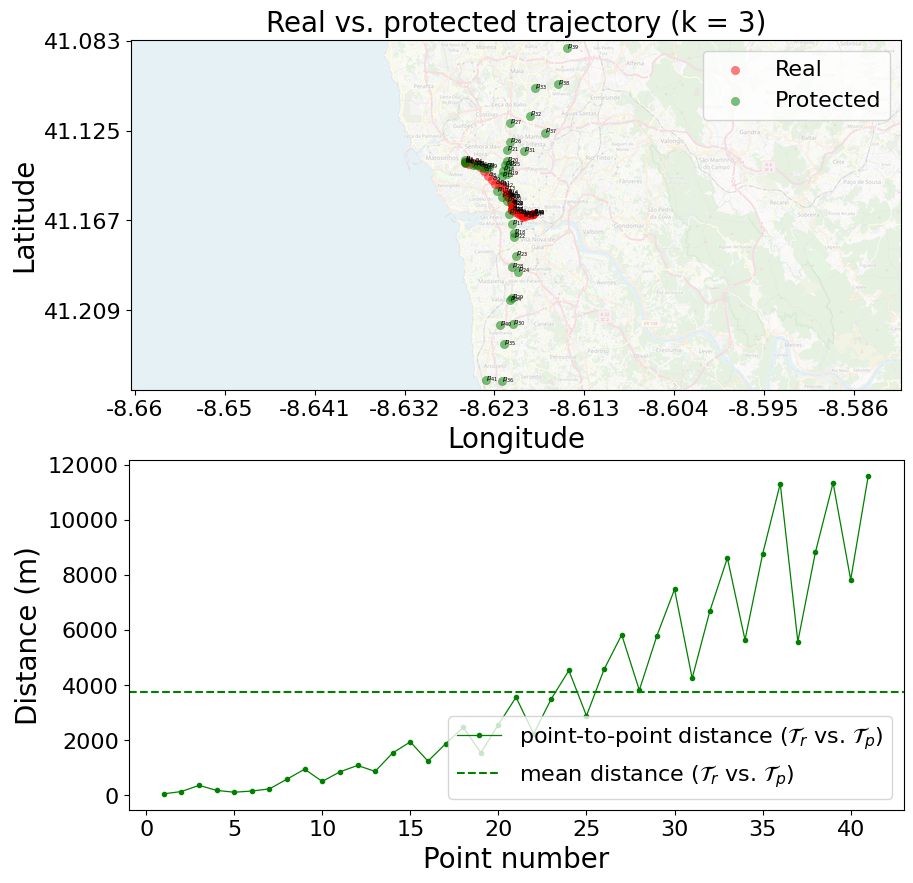

Point-to-point distance between the real and protected trajectory:
[np.float64(47.96908706378516), np.float64(130.64903237513298), np.float64(354.6075817749555), np.float64(173.1310339426896), np.float64(105.26130890077842), np.float64(148.8839687325935), np.float64(226.85390005261982), np.float64(581.5839583743054), np.float64(941.1151920049183), np.float64(496.8374299554753), np.float64(846.1753463949265), np.float64(1077.826569983297), np.float64(862.1798773482177), np.float64(1534.8601571202885), np.float64(1933.1747927314404), np.float64(1233.6878173082603), np.float64(1862.697744773998), np.float64(2466.3914557878393), np.float64(1541.5521499988304), np.float64(2559.6613296761807), np.float64(3555.746552214572), np.float64(2225.338529209549), np.float64(3492.8175506553794), np.float64(4526.825260074683), np.float64(2880.214215205572), np.float64(4567.260226646667), np.float64(5822.130574521757), np.float64(3811.7827660348753), np.float64(5790.935186014727), np.float64(7471.442261

<Figure size 640x480 with 0 Axes>

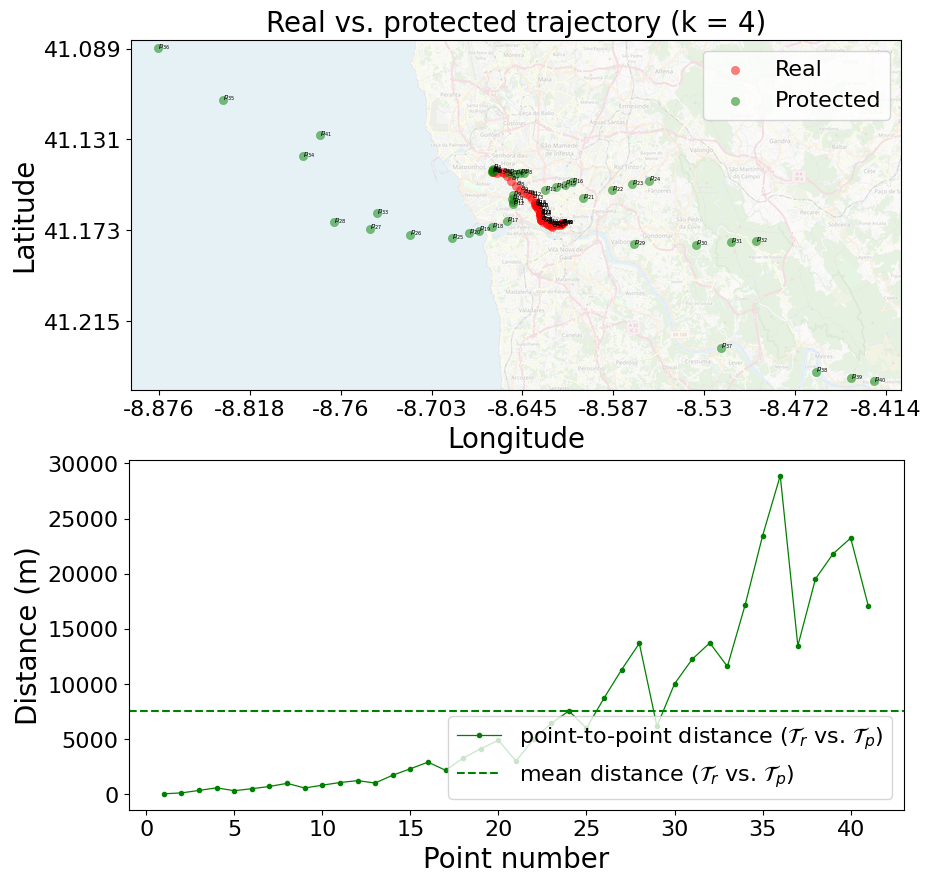

Point-to-point distance between the real and protected trajectory:
[np.float64(47.96908706378516), np.float64(130.64903237513298), np.float64(354.6075817749555), np.float64(590.6921922293657), np.float64(329.019321653091), np.float64(512.0907005654257), np.float64(714.5118416737253), np.float64(998.3515097208076), np.float64(574.4783465216804), np.float64(832.4747184781214), np.float64(1070.0562227825442), np.float64(1243.0680598133042), np.float64(1028.1358979698173), np.float64(1736.8765910289521), np.float64(2317.3074486943174), np.float64(2919.8843783191987), np.float64(2179.9343067875166), np.float64(3285.3496310506007), np.float64(4142.007311435683), np.float64(4898.653137086608), np.float64(3022.0183235912623), np.float64(5009.611881131722), np.float64(6431.468902234463), np.float64(7558.720346537147), np.float64(6000.947370115651), np.float64(8733.273990581676), np.float64(11315.937821908527), np.float64(13690.910857657529), np.float64(6169.569526101591), np.float64(10020.11359

In [6]:
# PLOTS for K experiments.

traj_id = 5

# Create deep copy Y_pred to avoid overwriting the original data
Y_test_cp = copy.deepcopy(Y_t)

# Denormalize the data
Y_test_dn = denormalize_data(dataset=Y_test_cp, normalization_ranges=normalization_ranges)

# Get the trajectory traj_id
actual = Y_test_dn[traj_id]

for i in range(1, 5):
    
    actuals = Y_t
    preds = Y_PREDS_Ks[i]

    # Create deep copy Y_pred to avoid overwriting the original data
    Y_pred_cp = copy.deepcopy(preds)
    
    # Denormalize the data
    Y_pred_dn = denormalize_data(dataset=Y_pred_cp, normalization_ranges=normalization_ranges)
    # print(Y_pred_dn)
    
    # Get the predicted trajectory traj_id
    predicted = Y_pred_dn[traj_id]

    # Compute the point-to-point distance between the real and protected trajectory
    dists = compute_point_to_point_haversine_distances(actual, predicted)

    lons_min_ext, lons_max_ext, lats_min_ext, lats_max_ext = plot_trajectory(real_traj = actual,
                protected_traj = predicted,
                dists = dists,
                save=True, 
                aspect_ratio=2.2,
                k=i)
    
    print("Point-to-point distance between the real and protected trajectory:")
    print (dists)
    print("Min/max longitudes and latitudes of the trajectories:")
    print(lons_min_ext, lons_max_ext, lats_min_ext, lats_max_ext)
    print("##################################")
    print("Mean distance between the real and protected trajectory (MDE_k):")
    print(np.mean(dists))
    print("##################################")

#### **Load Test Data and the Model (San Francisco dataset)** 

In [7]:
# Load the model generated by the training script from the 'training' folder
selected_dataset = "SANFRANCISCO"

subset = "test" # or "train" 

# Load trajectory data for faster execution
data = load_data_from_pickle(DATASET[selected_dataset], TOTAL_TRAJS)

# Get the data in the selected square
data = get_data_in_square(data = data, square = DATA_SQUARE[selected_dataset])

# Get trajectories min and max values
mins, maxs =  get_min_max_from_data(data)

# Normalize the data using the min and max values
normalization_ranges = {"min": mins, "max": maxs}

# Get number of trajectories
num_of_traj = len(data)

# Only keep the lat and lon columns for now
data = [data[i][COLUMNS] for i in range(num_of_traj)]

# Normalize the data using scaler or normalization ranges
scaler, data = normalize_trajectory_data(dataset = data, normalization_type = 'min-max')

# Load the test data
X_t = load_pickle(DATA_FOLDER + selected_dataset.lower() + "_X_"+subset+".pkl") # the input trajectory data
Y_t = load_pickle(DATA_FOLDER + selected_dataset.lower() + "_Y_"+subset+".pkl") # the true values of the trajectory data
traj_seq_lengths = load_pickle(DATA_FOLDER + selected_dataset.lower() + "_seq_len_"+subset+".pkl") # the sequence lenght of the input trajectory data

# Save the model
mdl = load_pickle(MODEL_FOLDER + "mdlgru-"+selected_dataset.lower()+".pkl")

# Model for BS = 1
model_sl = create_GRU_model(GRU_cells= LSTM_CELLS,
                          seq_len = 1,
                          num_feat = NUM_FEATS,
                          batch_size = 1,
                          stateful = True,
                          return_seq = RETURN_SEQ,
                          num_outputs = NUM_OUTPUTS,
                          LR = LR,
                          SEED = SEED,
                          ragged = False)


# Set weights and states
model_sl.set_weights(mdl.get_weights())


#### **Experiment 2 (SanFrancisco dataset) - Fixed k-** 

In [8]:
# Test Fixed K
n_trajs = 10

Y_PREDS_Ks = {}

save_pickle(Y_t[:n_trajs], DATA_FOLDER + selected_dataset.lower() + "_Y_test_fixed_k_ntrajs_" + str(n_trajs) + ".pkl")
save_pickle(traj_seq_lengths[:n_trajs], DATA_FOLDER + selected_dataset.lower() + "_test_seq_len_fixed_k_ntrajs_" + str(n_trajs) + ".pkl")

for k in range(1, 6):
    print("Generating trajectories with k = " + str(k))
    
    # Generate the trajectories using the APU Trajectory Generator with fixed k
    # The function apu_trajgen_fixed_k generates trajectories with a fixed k value
    # It uses the model_sl, input trajectory data X_t, sequence lengths traj_seq_lengths,
    # and other parameters to generate the trajectories.
    Y_pred_k = apu_trajgen_fixed_k(mdl = model_sl,
                                X_t = copy.deepcopy(X_t)[:n_trajs],
                                test_traj_seq_lengths = traj_seq_lengths,
                                SEQ_LENGTH = 1,
                                NUM_FEATS = NUM_FEATS,
                                k_steps=k)
    
    
    # Save the generated trajectories
    save_pickle(Y_pred_k, DATA_FOLDER + selected_dataset.lower() + "_Y_pred_fixed_k_" + str(k) + "_ntrajs_" + str(n_trajs) + ".pkl")
    
    Y_PREDS_Ks[k] = Y_pred_k

Generating trajectories with k = 1
Processing trajectory: 0
Processing trajectory: 1
Processing trajectory: 2
Processing trajectory: 3
Processing trajectory: 4
Processing trajectory: 5
Processing trajectory: 6
Processing trajectory: 7
Processing trajectory: 8
Processing trajectory: 9
Generating trajectories with k = 2
Processing trajectory: 0
Processing trajectory: 1
Processing trajectory: 2
Processing trajectory: 3
Processing trajectory: 4
Processing trajectory: 5
Processing trajectory: 6
Processing trajectory: 7
Processing trajectory: 8
Processing trajectory: 9
Generating trajectories with k = 3
Processing trajectory: 0
Processing trajectory: 1
Processing trajectory: 2
Processing trajectory: 3
Processing trajectory: 4
Processing trajectory: 5
Processing trajectory: 6
Processing trajectory: 7
Processing trajectory: 8
Processing trajectory: 9
Generating trajectories with k = 4
Processing trajectory: 0
Processing trajectory: 1
Processing trajectory: 2
Processing trajectory: 3
Processing

#### **Plot a Trajectory** 

<Figure size 640x480 with 0 Axes>

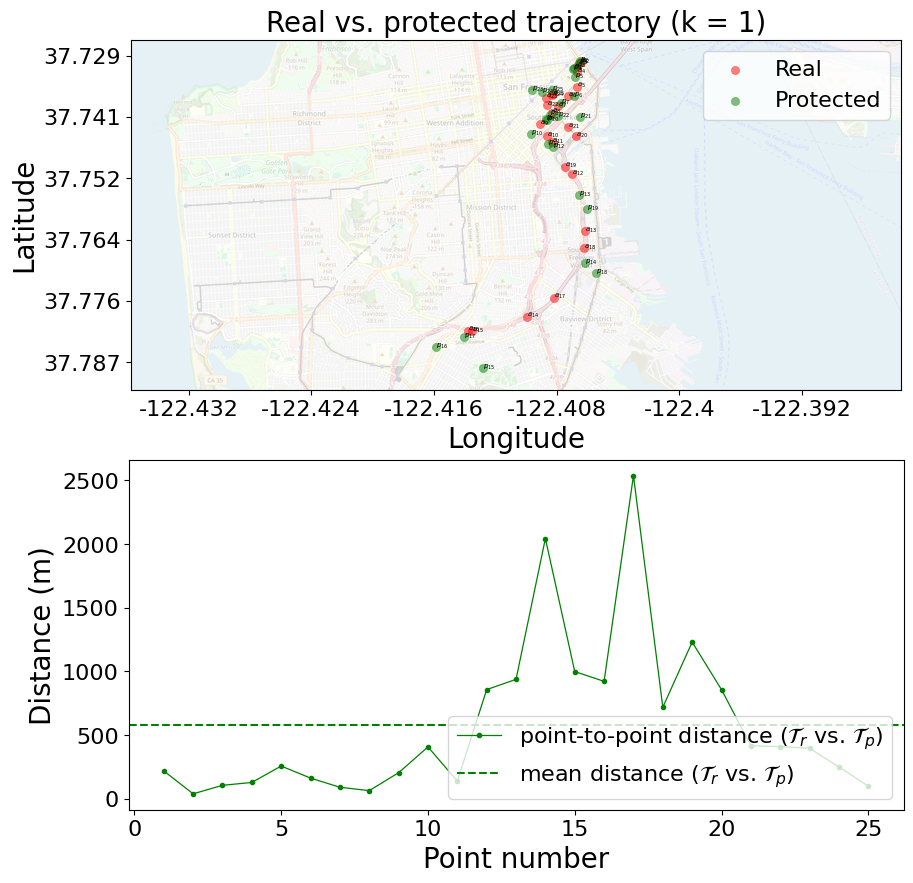

Point-to-point distance between the real and protected trajectory:
[np.float64(218.9989510127499), np.float64(39.10782433897588), np.float64(105.84805132798921), np.float64(128.2532607147479), np.float64(257.10212246987436), np.float64(162.5439866420891), np.float64(90.74053156316195), np.float64(63.96410271606552), np.float64(204.8271419795469), np.float64(407.26452483800756), np.float64(138.68644899385725), np.float64(857.3360521959625), np.float64(937.8766095586794), np.float64(2043.745217460041), np.float64(999.2773934055086), np.float64(922.0705203869315), np.float64(2537.4242162685455), np.float64(718.9061072148045), np.float64(1230.6319749858876), np.float64(856.9269918819164), np.float64(417.0679596829228), np.float64(409.5725309858277), np.float64(396.3838133517376), np.float64(249.36483524306038), np.float64(99.9348350931943)]
Min/max longitudes and latitudes of the trajectories:
-122.44031516836493 -122.38351832652033 37.71753193533421 37.79874321531296
#####################

<Figure size 640x480 with 0 Axes>

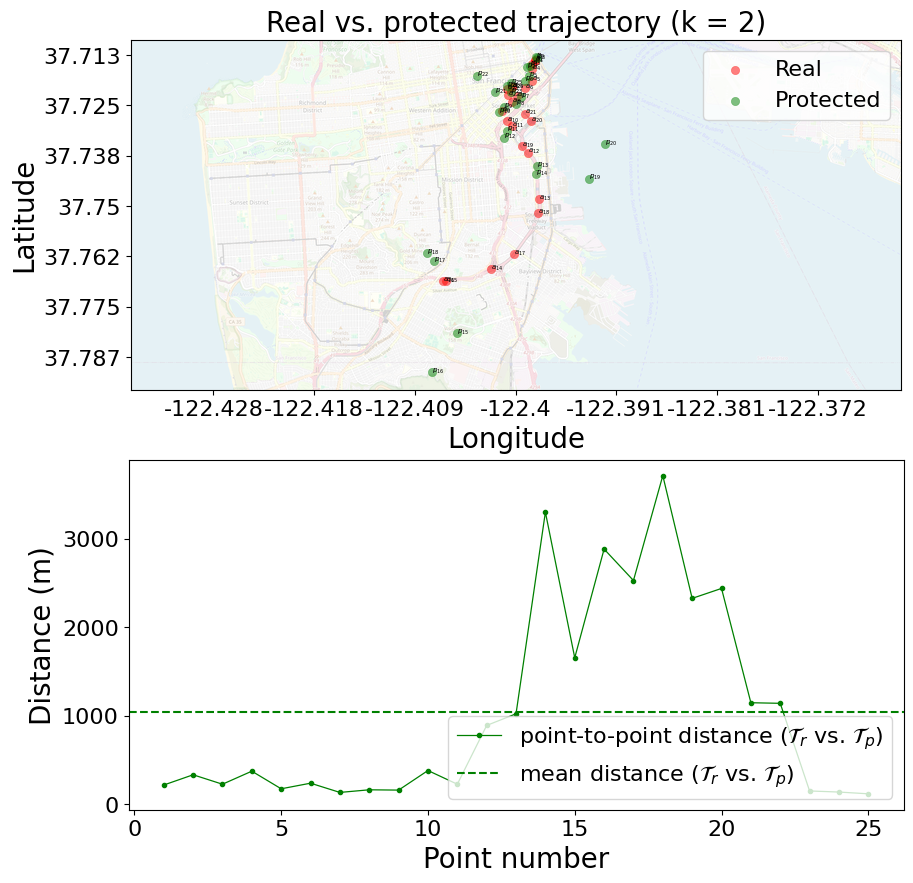

Point-to-point distance between the real and protected trajectory:
[np.float64(218.9989510127499), np.float64(334.4935018686992), np.float64(228.24797207218165), np.float64(375.0936258537489), np.float64(176.533057313576), np.float64(239.66731741587418), np.float64(135.5419376696596), np.float64(165.07999058749408), np.float64(161.70891019552806), np.float64(382.59842424367883), np.float64(228.10128291974354), np.float64(891.0876913399602), np.float64(1022.4597257449686), np.float64(3297.4155130410886), np.float64(1654.762205891165), np.float64(2880.9566853177284), np.float64(2526.3370237090026), np.float64(3709.482507903656), np.float64(2324.753680403118), np.float64(2436.8341271015743), np.float64(1147.4217083233498), np.float64(1140.7809128795227), np.float64(152.13982422902205), np.float64(139.68720164304852), np.float64(119.83651903851937)]
Min/max longitudes and latitudes of the trajectories:
-122.43677534258633 -122.36288003129542 37.70048980138779 37.79938254893303
############

<Figure size 640x480 with 0 Axes>

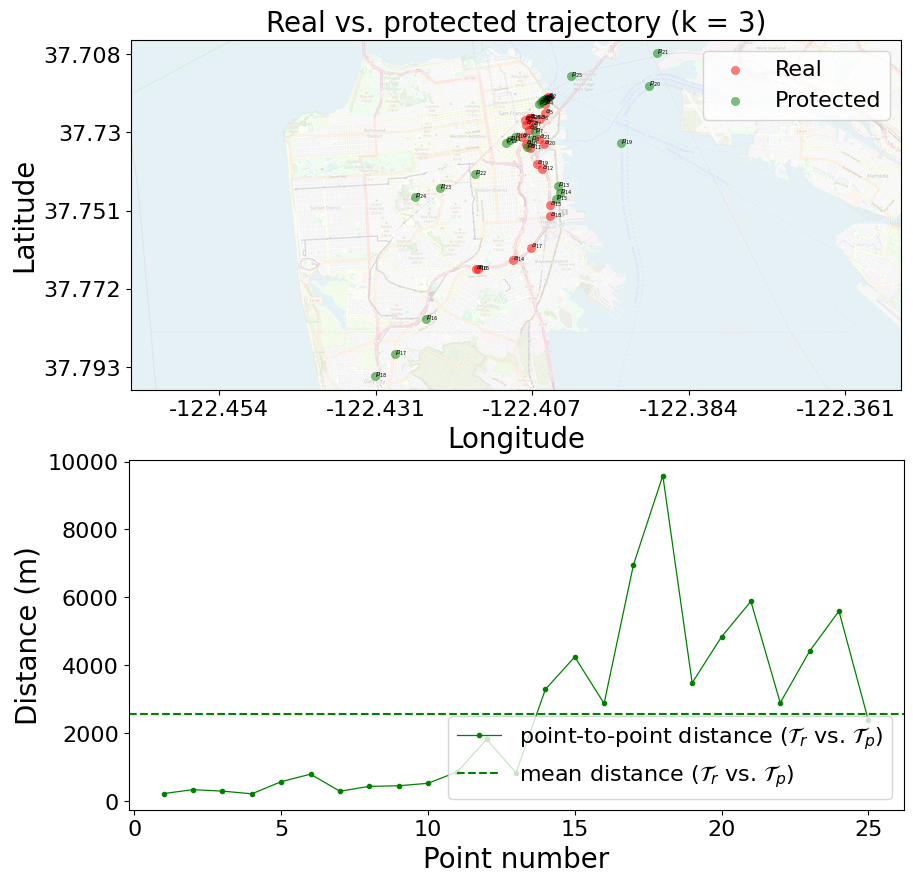

Point-to-point distance between the real and protected trajectory:
[np.float64(218.9989510127499), np.float64(334.4935018686992), np.float64(290.8530450698869), np.float64(211.52542504124062), np.float64(569.4189215258833), np.float64(790.1380486369545), np.float64(287.2893471032924), np.float64(431.14035783580124), np.float64(449.17567830070146), np.float64(521.2663306237988), np.float64(858.2859795492451), np.float64(1814.696740928043), np.float64(830.2160835655544), np.float64(3287.790150471963), np.float64(4245.67355894652), np.float64(2872.923693659721), np.float64(6959.324517091191), np.float64(9586.674161588831), np.float64(3479.7668712848754), np.float64(4836.997430201596), np.float64(5882.590593178423), np.float64(2892.6521398801697), np.float64(4413.001402481544), np.float64(5595.221297105744), np.float64(2382.4970669331674)]
Min/max longitudes and latitudes of the trajectories:
-122.47749217917725 -122.3374807003373 37.687217731257675 37.81448584032059
######################

<Figure size 640x480 with 0 Axes>

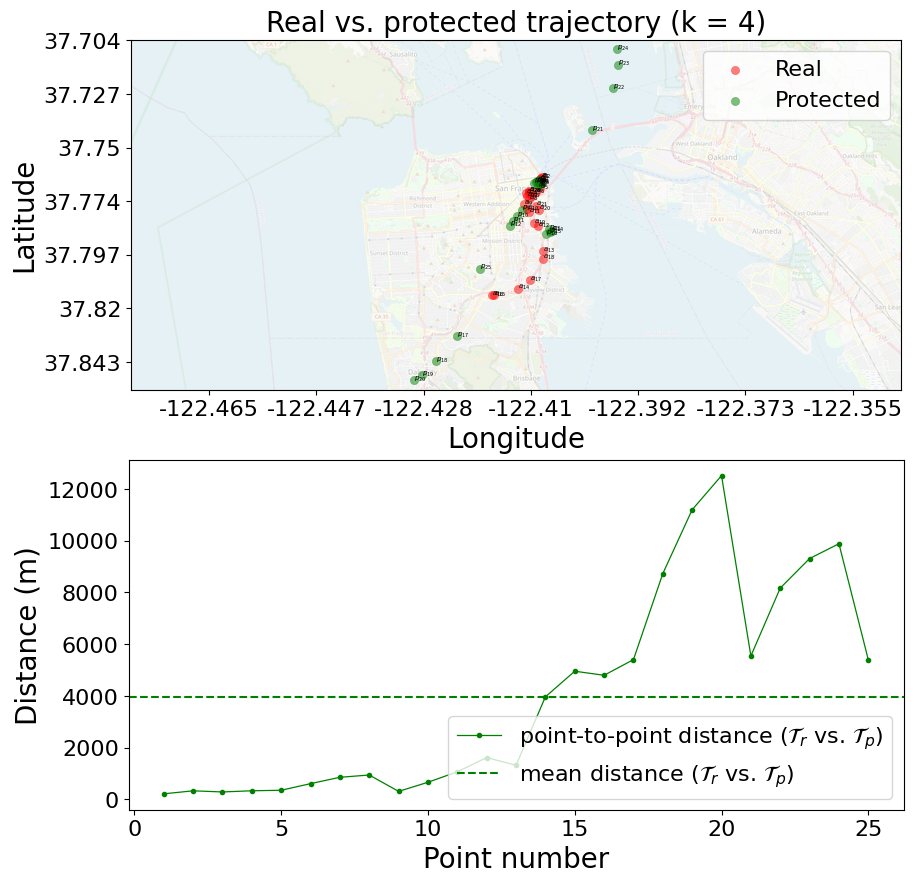

Point-to-point distance between the real and protected trajectory:
[np.float64(218.9989510127499), np.float64(334.4935018686992), np.float64(290.8530450698869), np.float64(336.33114791435634), np.float64(356.4353071033795), np.float64(612.0846784935129), np.float64(857.3320990909226), np.float64(945.4129127212208), np.float64(313.60967546910234), np.float64(664.971142328063), np.float64(1070.1304714723897), np.float64(1619.5068306579235), np.float64(1320.989638807398), np.float64(3964.503144974083), np.float64(4956.065481355618), np.float64(4798.521683841857), np.float64(5403.120096198961), np.float64(8726.709213478667), np.float64(11194.969001150055), np.float64(12512.250582960314), np.float64(5544.881079740502), np.float64(8166.760119293585), np.float64(9309.78380022555), np.float64(9880.52524495011), np.float64(5399.318554972052)]
Min/max longitudes and latitudes of the trajectories:
-122.48372484922915 -122.33625857474328 37.68077796994686 37.86648017400742
########################

In [9]:
# PLOTS for K experiments.
traj_id = 8

# Create deep copy Y_pred to avoid overwriting the original data
Y_test_cp = copy.deepcopy(Y_t)

# Denormalize the data
normalization_ranges = {"min": mins[0:NUM_OUTPUTS], "max": maxs[0:NUM_OUTPUTS]}
Y_test_dn = denormalize_data(dataset=Y_test_cp, normalization_ranges=normalization_ranges)

# Get the trajectory traj_id
actual = Y_test_dn[traj_id]

for i in range(1, 5):
    
    actuals = Y_t
    preds = Y_PREDS_Ks[i]

    # Create deep copy Y_pred to avoid overwriting the original data
    Y_pred_cp = copy.deepcopy(preds)
    
    # Denormalize the data
    Y_pred_dn = denormalize_data(dataset=Y_pred_cp, normalization_ranges=normalization_ranges)
    
    # Get the predicted trajectory traj_id
    predicted = Y_pred_dn[traj_id]

    # Compute the point-to-point distance between the real and protected trajectory
    dists = compute_point_to_point_haversine_distances(actual, predicted)
    
    # Plot the trajectories
    lons_min_ext, lons_max_ext, lats_min_ext, lats_max_ext = plot_trajectory(real_traj = actual,
                protected_traj = predicted,
                dists = dists,
                save=True, 
                aspect_ratio=2.2,
                k=i)
    
    print("Point-to-point distance between the real and protected trajectory:")
    print (dists)
    print("Min/max longitudes and latitudes of the trajectories:")
    print(lons_min_ext, lons_max_ext, lats_min_ext, lats_max_ext)
    print("##################################")
    print("Mean distance between the real and protected trajectory (MDE_k):")
    print(np.mean(dists))
    print("##################################")